# 01 · Figuras para presentación y documento
## Distribución geográfica y por split del dataset

Genera figuras de calidad publicación para el TFM y la presentación de defensa.

**Salida:** `Outputs/ResultsChapter_101622_101840/Figures_General/`

Ejecutar desde la raíz del repositorio:
```
cd /data/users/kabasmen/MethaneProjectTFM
jupyter notebook Notebooks/01_FigurasDistribucionDataset.ipynb
```

In [52]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

ProjectRoot = Path("/data/users/kabasmen/MethaneProjectTFM")
sys.path.append(str(ProjectRoot))

# Rutas de entrada y salida
RunTag        = "Exp271431"
TablesRoot    = ProjectRoot / "Outputs" / "Experiments" / RunTag / "Tables"
FIGURE_DIR    = ProjectRoot / "Outputs" / "ResultsChapter_101622_101840" / "Figures_General"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("TablesRoot:", TablesRoot)
print("FIGURE_DIR:", FIGURE_DIR)

TablesRoot: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/Tables
FIGURE_DIR: /data/users/kabasmen/MethaneProjectTFM/Outputs/ResultsChapter_101622_101840/Figures_General


In [53]:
# ─── Paleta de colores del proyecto ───────────────────────────────────────
COLORS = {
    "dark":       "#042C53",
    "navy":       "#0C447C",
    "blue":       "#034591",
    "mid_blue":   "#0099FF",
    "light_blue": "#0DACEB78",
    "pale":       "#E6F1FB",
    "bg":         "#F7F9FC",
    "grid":       "#D8E8F7",
    "text":       "#042C53",
    "border":     "#B5D4F4",
    "accent":     "#5DB7E8",
}

SPLIT_COLORS = {
    "Train":      COLORS["navy"],
    "Validation": COLORS["mid_blue"],
    "Test":       COLORS["light_blue"],
}

FONT = "Montserrat"

def ApplyStyle():
    """Aplica estilo global consistente con el TFM."""
    available = [f.name for f in mpl.font_manager.fontManager.ttflist]
    font = FONT if FONT in available else "DejaVu Sans"
    mpl.rcParams.update({
        "font.family":          font,
        "figure.facecolor":     "white",
        "axes.facecolor":       "white",
        "savefig.facecolor":    "white",
        "axes.edgecolor":       COLORS["border"],
        "axes.linewidth":       1.4,
        "axes.labelcolor":      COLORS["text"],
        "axes.titlecolor":      COLORS["navy"],
        "xtick.color":          COLORS["text"],
        "ytick.color":          COLORS["text"],
        "text.color":           COLORS["text"],
        "axes.grid":            True,
        "grid.color":           COLORS["grid"],
        "grid.alpha":           0.6,
        "grid.linewidth":       0.8,
        "axes.spines.top":      False,
        "axes.spines.right":    False,
        "axes.titlesize":       16,
        "axes.labelsize":       13,
        "xtick.labelsize":      11,
        "ytick.labelsize":      11,
        "legend.fontsize":      11,
        "figure.titlesize":     18,
    })

def StyleAxes(ax, title=None, xlabel=None, ylabel=None):
    if title:   ax.set_title(title, fontweight="bold", color=COLORS["navy"], pad=10)
    if xlabel:  ax.set_xlabel(xlabel, color=COLORS["text"])
    if ylabel:  ax.set_ylabel(ylabel, color=COLORS["text"])
    for spine in ax.spines.values():
        spine.set_color(COLORS["border"])
        spine.set_linewidth(1.2)
    ax.grid(True, color=COLORS["grid"], alpha=0.6, linewidth=0.8)

def SaveFig(fig, name, dpi=220):
    path = FIGURE_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Guardada: {path}")

ApplyStyle()
print("Estilo aplicado.")

Estilo aplicado.


## 1. Carga del dataset

In [3]:
DatasetFiltered = pd.read_csv(TablesRoot / "DatasetFiltered.csv")
print("DatasetFiltered:", DatasetFiltered.shape)
print("Columnas disponibles:", DatasetFiltered.columns.tolist())
DatasetFiltered.head(3)

DatasetFiltered: (3519, 46)
Columnas disponibles: ['SampleId', 'type', 'detection:case_study', 'detection:ch4_fluxrate', 'detection:ch4_fluxrate_std', 'detection:isplume', 'detection:offshore', 'detection:sector', 'detection:wind_source', 'geoenrich:admin_countries', 'geoenrich:admin_districts', 'geoenrich:admin_states', 'geoenrich:elevation', 'geoenrich:population', 'geoenrich:temperature', 'majortom:code', 'meteo:wind_u', 'meteo:wind_v', 'plume:geometry', 'quality:last_update', 'quality:notified', 'quality:observability', 'quality:percentage_clear', 'satellite:background_tile', 'satellite:platform', 'satellite:sza', 'satellite:tile', 'satellite:vza', 'site:country', 'site:location_name', 'split', 'stac:centroid', 'stac:crs', 'stac:geotransform', 'stac:tensor_shape', 'stac:time_end', 'stac:time_middle', 'stac:time_start', 'internal:gdal_vsi', 'Products', 'HasTarget', 'HasReference', 'HasPlume', 'HasCH4', 'HasDem', 'ProductCount']


,SampleId,type,detection:case_study,detection:ch4_fluxrate,detection:ch4_fluxrate_std,detection:isplume,detection:offshore,detection:sector,detection:wind_source,geoenrich:admin_countries,...,stac:time_middle,stac:time_start,internal:gdal_vsi,Products,HasTarget,HasReference,HasPlume,HasCH4,HasDem,ProductCount
0,681256b9-41d5-4d9d-9063-d5fa17773661,FOLDER,Algeria,4651.1840,1471.3221,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,...,NaN,2024-10-06 10:00:29,"/vsisubfile/861911689_3746,/data/databases/MET...",ch4|dem|plume|reference|target,True,True,True,True,True,5
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,FOLDER,Algeria,7756.5000,2941.1950,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,...,NaN,2024-06-13 10:00:31,"/vsisubfile/864059967_3750,/data/databases/MET...",ch4|dem|plume|reference|target,True,True,True,True,True,5
2,101031f1-3f77-4029-9172-fee5b35a6e5f,FOLDER,Algeria,7360.7646,2060.4246,True,False,Oil and Gas,NASA/GEOS-FP,Algeria,...,NaN,2024-04-24 10:00:31,"/vsisubfile/860580608_3738,/data/databases/MET...",ch4|dem|plume|reference|target,True,True,True,True,True,5


In [50]:
# Detectar columna de país y de split automáticamente
country_col = next(
    (c for c in DatasetFiltered.columns if "country" in c.lower()),
    None
)
split_col = next(
    (c for c in DatasetFiltered.columns if c.lower() in ("split", "partition", "subset")),
    None
)

print(f"Columna de país detectada : {country_col}")
print(f"Columna de split detectada: {split_col}")

# Limpiar nombre de país
if country_col:
    DatasetFiltered["Country"] = DatasetFiltered[country_col].str.strip()

# Asignar Split desde archivos separados si no hay columna
if split_col is None:
    print("\nNo hay columna de split en DatasetFiltered — leyendo SplitTrain/Validation/Test.csv")
    def load_split(name):
        path = TablesRoot / f"Split{name}.csv"
        if path.exists():
            df = pd.read_csv(path)
            df["Split"] = name
            return df
        return pd.DataFrame()

    splits_df = pd.concat([load_split(s) for s in ["Train", "Validation", "Test"]], ignore_index=True)

    # Identificar columna de id
    id_col = next(
        (c for c in DatasetFiltered.columns if c.lower() in ("id", "sampleid", "sample_id")),
        DatasetFiltered.columns[0]
    )
    split_id_col = next(
        (c for c in splits_df.columns if c.lower() in ("id", "sampleid", "sample_id")),
        splits_df.columns[0] if len(splits_df.columns) else "id"
    )
    DatasetFiltered = DatasetFiltered.merge(
        splits_df[[split_id_col, "Split"]].rename(columns={split_id_col: id_col}),
        on=id_col, how="left"
    )
    split_col = "Split"
else:
    DatasetFiltered = DatasetFiltered.rename(columns={split_col: "Split"})
    split_col = "Split"

# Normalizar valores del split
split_map = {"train": "Train", "val": "Validation", "validation": "Validation", "test": "Test"}
DatasetFiltered["Split"] = DatasetFiltered["Split"].map(
    lambda x: split_map.get(str(x).lower(), str(x)) if pd.notna(x) else x
)

print("\nDistribución de splits:")
print(DatasetFiltered["Split"].value_counts())
print("\nTotal muestras:", len(DatasetFiltered))

Columna de país detectada : site:country
Columna de split detectada: Split

Distribución de splits:
Split
Train         2463
Test           528
Validation     528
Name: count, dtype: int64

Total muestras: 3519


In [5]:
# Forzar lectura desde los archivos del experimento — ignorar split de TACOv2
def load_split(name):
    path = TablesRoot / f"Split{name}.csv"
    if path.exists():
        df = pd.read_csv(path)
        df["Split"] = name
        return df
    return pd.DataFrame()

splits_df = pd.concat(
    [load_split(s) for s in ["Train", "Validation", "Test"]],
    ignore_index=True
)

id_col = next(
    (c for c in DatasetFiltered.columns if c.lower() in ("id", "sampleid", "sample_id")),
    DatasetFiltered.columns[0]
)
split_id_col = next(
    (c for c in splits_df.columns if c.lower() in ("id", "sampleid", "sample_id")),
    splits_df.columns[0]
)

# Eliminar cualquier columna Split preexistente de DatasetFiltered
if "Split" in DatasetFiltered.columns:
    DatasetFiltered = DatasetFiltered.drop(columns=["Split"])

DatasetFiltered = DatasetFiltered.merge(
    splits_df[[split_id_col, "Split"]].rename(columns={split_id_col: id_col}),
    on=id_col, how="left"
)

print("Partición del experimento 271431:")
print(DatasetFiltered["Split"].value_counts())

Partición del experimento 271431:
Split
Train         2463
Test           528
Validation     528
Name: count, dtype: int64


## 2. Figura 1 — Muestras por país y split

Guardada: /data/users/kabasmen/MethaneProjectTFM/Outputs/ResultsChapter_101622_101840/Figures_General/Fig07_MapaDistribucionGlobal_Coropleta_Conectores.png


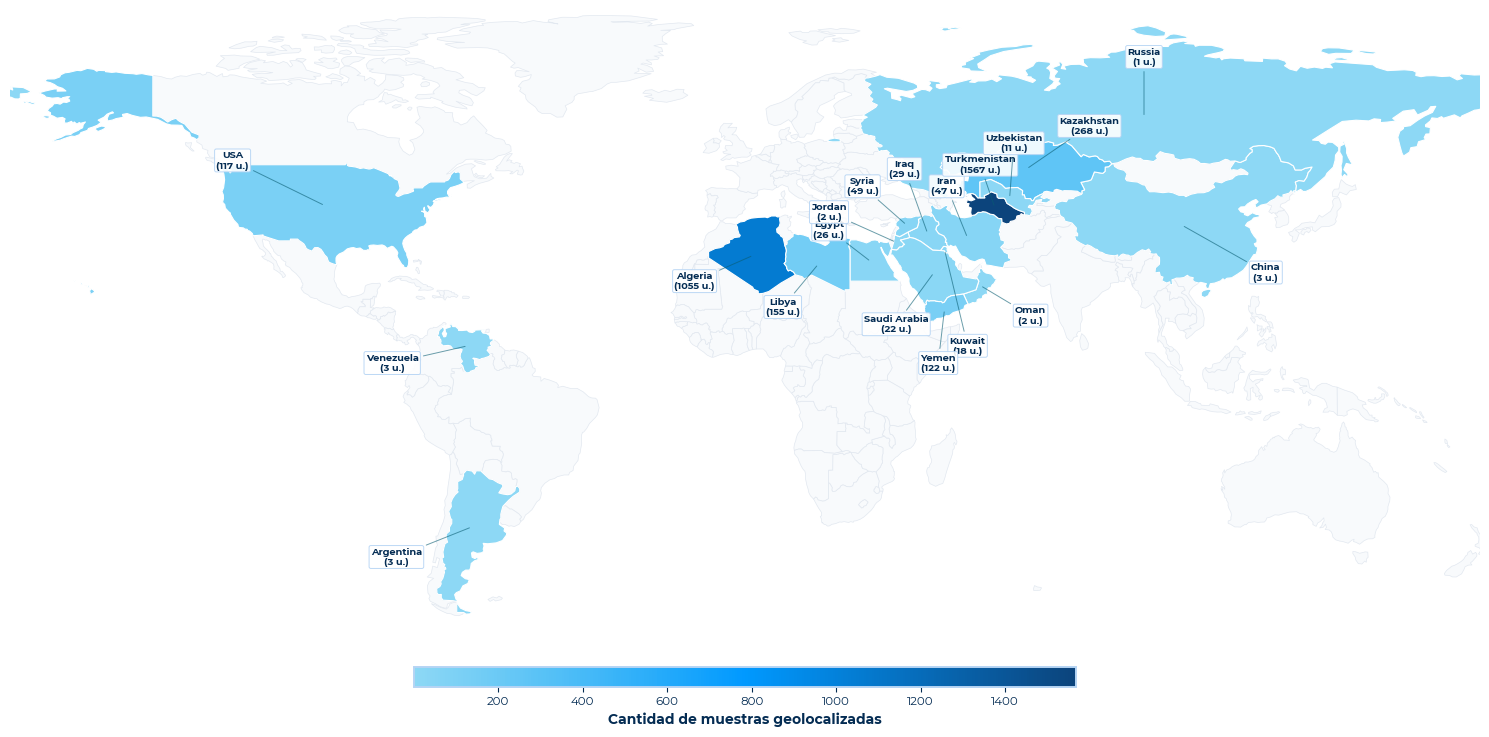

In [51]:
# ─── FIGURA 7: MAPA DE DISTRIBUCIÓN GLOBAL (CORREGIDO SIN SOLAPAMIENTOS) ───
import geopandas as gpd
import ssl
import urllib.request
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Agrupar datos por país usando el DataFrame disponible en tu celda
country_counts = DatasetFiltered["Country"].value_counts().reset_index()
country_counts.columns = ["Country", "Muestras"]

# 2. Diccionario de homologación exhaustivo para emparejar con el GeoJSON
def normalize_country_name(name):
    n = str(name).strip().lower()
    mapping = {
        "usa": "united states",
        "united states of america": "united states",
        "united states": "united states",
        "russian federation": "russia",
        "russian fed.": "russia",
        "iran (islamic republic of)": "iran",
        "syrian arab republic": "syria",
        "dem. rep. congo": "democratic republic of the congo",
        "united kingdom": "united kingdom",
        "uk": "united kingdom"
    }
    return mapping.get(n, n)

country_counts["Country_Clean"] = country_counts["Country"].apply(normalize_country_name)

# 3. Descarga del mapa base mundial
ssl_context = ssl._create_unverified_context()
world_geojson_url = "https://raw.githubusercontent.com/datasets/geo-boundaries-world-110m/master/countries.geojson"

try:
    with urllib.request.urlopen(world_geojson_url, context=ssl_context) as response:
        geojson_data = json.loads(response.read().decode())
    world = gpd.GeoDataFrame.from_features(geojson_data)
except Exception as e:
    raise RuntimeError(f"No se pudo descargar el mapa mundial: {e}")

if world.crs is None:
    world.set_crs(epsg=4326, inplace=True)

# Identificar la columna de nombres en el GeoJSON y normalizarla
name_col = "name" if "name" in world.columns else ("NAME" if "NAME" in world.columns else world.columns[0])
world["Country_Clean"] = world[name_col].astype(str).str.strip().str.lower()

# 4. Fusión de datos (Merge)
world_merged = world.merge(country_counts, on="Country_Clean", how="left")
world_merged["Muestras"] = world_merged["Muestras"].fillna(0).astype(int)

# 5. Diseño del lienzo
fig, ax = plt.subplots(figsize=(15, 8.5), facecolor="white")
ax.set_facecolor("white")
ax.set_aspect('equal')

# A. Dibujar fondo de países sin muestras (Gris premium muy limpio)
world_merged[world_merged["Muestras"] == 0].plot(
    ax=ax,
    color="#F8FAFC",      # Gris slate ultra suave
    edgecolor="#E2E8F0",  # Fronteras sutiles
    linewidth=0.5,
    zorder=1
)

# B. Colorear los países activos (Coropleto)
df_active = world_merged[world_merged["Muestras"] > 0].copy()

# Colores de respaldo por si no está la paleta corporativa COLORS
try:
    c_light = COLORS["light_blue"]
    c_mid = COLORS["mid_blue"]
    c_navy = COLORS["navy"]
    c_dark = COLORS["dark"]
except NameError:
    c_light = "#49BFFF"  # Sky 200
    c_mid = "#00476B"    # Sky 600
    c_navy = "#0F172A"   # Slate 900
    c_dark = "#1E293B"   # Slate 800
    COLORS = {"navy": c_navy, "dark": c_dark, "border": "#CBD5E1"}

cmap_custom = mcolors.LinearSegmentedColormap.from_list("custom_blues", [c_light, c_mid, c_navy])
norm_linear = mcolors.Normalize(vmin=1, vmax=df_active["Muestras"].max() if not df_active.empty else 100)

if not df_active.empty:
    df_active.plot(
        ax=ax,
        column="Muestras",
        cmap=cmap_custom,
        norm=norm_linear,
        edgecolor="white",
        linewidth=0.8,
        zorder=2
    )

# Calcular centroide para las posiciones de anclaje
df_active["centroid"] = df_active.to_crs("+proj=cea").centroid.to_crs(world.crs)
df_active["lon"] = df_active["centroid"].x
df_active["lat"] = df_active["centroid"].y

# C. RE-PROYECCIÓN EN RADIAL EVITANDO SOLAPAMIENTOS EN MEDIO ORIENTE
# Estructura: "key_pais": ((lon_real_anclaje, lat_real_anclaje), (lon_etiqueta_desplazada, lat_etiqueta_desplazada))
LABEL_ANNOTATIONS = {
    # América
    "united states": ((-100.0, 39.5), (-122.0, 50.0)),
    "venezuela": ((-66.0, 7.0), (-84.0, 3.0)),
    "argentina": ((-65.0, -35.0), (-83.0, -42.0)),
    
    # Eurasia Extrema e Interiores
    "russia": ((95.0, 60.0), (95.0, 74.0)),
    "china": ((104.0, 35.0), (124.0, 24.0)),
    "kazakhstan": ((67.0, 48.0), (82.0, 58.0)),
    
    # África
    "algeria": ((2.0, 28.0), (-12.0, 22.0)),
    "libya": ((17.5, 26.0), (9.0, 16.0)),
    "egypt": ((30.0, 26.5), (20.0, 34.0)),
    
    # ─── DISPERSIÓN DE ORIENTE MEDIO EN ABANICO RADIAL DESPEJADO ───
    "syria": ((38.5, 35.0), (28.0, 44.0)),         # Hacia el Noroeste exterior lejano
    "jordan": ((36.0, 31.0), (20.0, 38.0)),        # Hacia el Oeste lejano (sobre el Mediterráneo)
    "iraq": ((43.5, 33.0), (38.0, 48.0)),          # Directo al Norte
    "iran": ((53.0, 32.0), (48.0, 44.0)),          # Al Norte-Noroeste
    "turkmenistan": ((59.5, 39.0), (56.0, 49.0)),  # Al Norte sobre el Caspio
    "uzbekistan": ((63.0, 41.2), (64.0, 54.0)),    # Más arriba hacia el Norte sobre Kazajistán
    
    # Proyecciones hacia el Sur y el Océano Índico
    "saudi arabia": ((45.0, 24.0), (36.0, 12.0)),  # Hacia el Suroeste (Mar Rojo)
    "yemen": ((47.5, 15.5), (46.0, 3.0)),          # Directo al Sur en el Golfo de Adén
    "kuwait": ((47.5, 29.3), (53.0, 7.0)),         # Hacia el Sur-Sureste (muy estirado abajo)
    "bahrain": ((50.5, 26.0), (60.0, 8.0)),        # Desplazado al Sureste en el agua
    "oman": ((56.0, 21.0), (68.0, 14.0))           # Hacia el Este-Sureste (Mar Arábigo)
}

for _, row in df_active.iterrows():
    c_clean = row["Country_Clean"]
    muestras = int(row["Muestras"])
    
    display_name = str(row[name_col])
    if "United States" in display_name or "America" in display_name: 
        display_name = "USA"
    elif "Russian" in display_name: 
        display_name = "Russia"
    elif "Iran" in display_name:
        display_name = "Iran"
    elif "Syrian" in display_name:
        display_name = "Syria"
        
    label_text = f"{display_name}\n({muestras} u.)"
    
    if c_clean in LABEL_ANNOTATIONS:
        xy_coord, xy_text = LABEL_ANNOTATIONS[c_clean]
        ax.annotate(
            label_text,
            xy=xy_coord,
            xytext=xy_text,
            color=COLORS["dark"],
            fontsize=7.0,            # Micro-tipografía compacta de alta legibilidad
            fontweight="bold",
            ha="center", va="center",
            arrowprops=dict(
                arrowstyle="-",
                color="#095D72",     # Línea gris suave y profesional
                linewidth=0.7,
                alpha=0.6
            ),
            bbox=dict(
                boxstyle="round,pad=0.18", # Margen súper optimizado para achicar las cajitas
                fc="white",
                ec=COLORS["border"],
                alpha=0.9,
                lw=0.7
            ),
            zorder=4
        )
    else:
        # Fallback de posicionamiento por si acaso
        ax.text(
            row["lon"], row["lat"],
            label_text,
            color=COLORS["dark"],
            fontsize=7.0,
            fontweight="bold",
            ha="center", va="center",
            zorder=4,
            bbox=dict(
                boxstyle="round,pad=0.18",
                fc="white",
                ec=COLORS["border"],
                alpha=0.9,
                lw=0.7
            )
        )

# D. Leyenda de color continua horizontal
if not df_active.empty:
    sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=norm_linear)
    sm._A = []
    cbar = fig.colorbar(
        sm, 
        ax=ax, 
        orientation="horizontal", 
        pad=0.06, 
        shrink=0.45, 
        aspect=32
    )
    cbar.set_label("Cantidad de muestras geolocalizadas", color=COLORS["dark"], fontsize=10, fontweight="bold")
    cbar.ax.tick_params(labelsize=8.5, colors=COLORS["dark"])


# Ajuste de bordes
ax.set_ylim(-56, 85)
ax.set_xlim(-175, 175)
ax.axis("off")

plt.tight_layout()

# Guardado seguro
try:
    SaveFig(fig, "Fig07_MapaDistribucionGlobal_Coropleta_Conectores.png")
except NameError:
    fig.savefig("Fig07_MapaDistribucionGlobal_Coropleta_Conectores.png", dpi=300, bbox_inches="tight")

plt.show()

In [16]:
paises_ordenados = sorted(DatasetFiltered["site:country"].dropna().unique())
print("Países ordenados alfabéticamente:")
for pais in paises_ordenados:
    print(f"- {pais}")

Países ordenados alfabéticamente:
- Algeria
- Argentina
- Bahrain
- China
- Egypt
- Iran (Islamic Republic of)
- Iraq
- Jordan
- Kazakhstan
- Kuwait
- Libya
- Oman
- Russian Federation
- Saudi Arabia
- Syrian Arab Republic
- Turkmenistan
- United States of America
- Uzbekistan
- Venezuela
- Yemen


Guardada: /data/users/kabasmen/MethaneProjectTFM/Outputs/ResultsChapter_101622_101840/Figures_General/Fig01_MuestrasPorPaisYSplit_Infografia_Largas.png


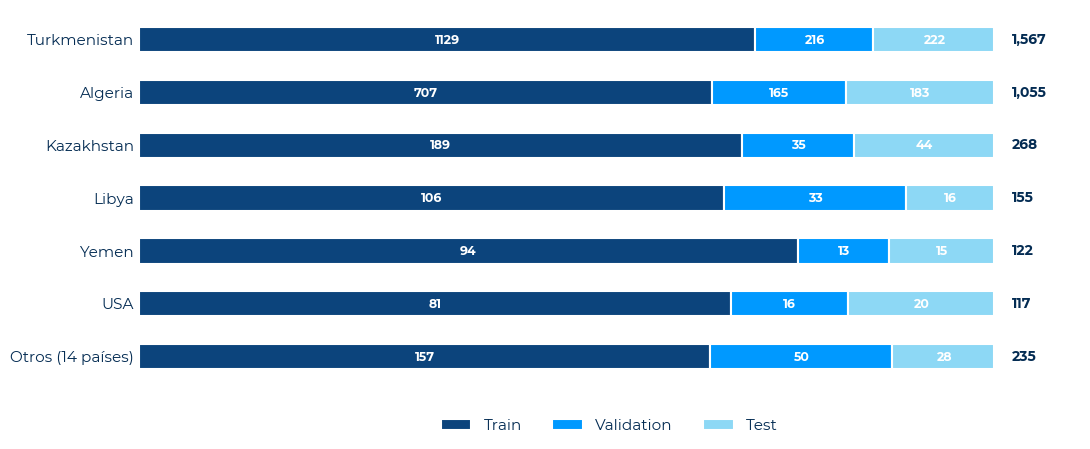

In [46]:
# ─── FIGURA 1: BARRAS APILADAS AL 100% (MÁXIMO ESPACIO PARA NÚMEROS) ────────
SPLIT_ORDER = ["Train", "Validation", "Test"]

# 1. Tabla país × split original
country_split = (
    DatasetFiltered.groupby(["Country", "Split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SPLIT_ORDER, fill_value=0)
)

# Calcular totales absolutos
country_split["Total"] = country_split.sum(axis=1)
country_split_sorted = country_split.sort_values("Total", ascending=False)

# 2. AGRUPAR LA LARGA COLA (Top 6 + Otros)
TOP_N = 6
top_countries = country_split_sorted.iloc[:TOP_N].copy()
others = country_split_sorted.iloc[TOP_N:].copy()

if len(others) > 0:
    others_row = others.sum(numeric_only=True)
    others_name = f"Otros ({len(others)} países)"
    top_countries.loc[others_name] = others_row

# Invertir para que la barra más grande quede arriba
chart_data = top_countries.iloc[::-1].copy()

# Nombres limpios sin emojis (evita cuadraditos vacíos)
CLEAN_NAMES = {
    "Turkmenistan": "Turkmenistan",
    "Algeria": "Algeria",
    "Kazakhstan": "Kazakhstan",
    "Libya": "Libya",
    "Yemen": "Yemen",
    "United States of America": "USA",
}
chart_data.index = [CLEAN_NAMES.get(idx, idx) for idx in chart_data.index]

countries = chart_data.index.tolist()
n = len(countries)

# ─── CLAVE: Normalizar filas a porcentajes (100%) para que midan lo mismo ───
chart_data_pct = chart_data[SPLIT_ORDER].div(chart_data["Total"], axis=0) * 100

# Crear la figura
fig, ax = plt.subplots(figsize=(11, max(4.5, n * 0.65)), facecolor="white")
ax.set_facecolor("white")

# 3. DIBUJAR BARRAS (Usando porcentajes para los anchos)
left = np.zeros(n)
for split in SPLIT_ORDER:
    pct_vals = chart_data_pct[split].values
    abs_vals = chart_data[split].values # Usamos los valores reales para las etiquetas
    
    bars = ax.barh(
        countries, pct_vals, left=left,
        color=SPLIT_COLORS[split],
        edgecolor="white", linewidth=1.5, # Borde blanco elegante divisor
        height=0.48, # Barras delgadas e infográficas
        label=split,
    )
    
    # Colocar los valores reales dentro de los segmentos (ahora sí caben perfectamente)
    for bar, abs_val in zip(bars, abs_vals):
        if abs_val > 0: # Solo pintar si hay datos en ese split
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{int(abs_val)}",
                ha="center", va="center",
                fontsize=9, color="white", fontweight="bold"
            )
    left += pct_vals

# 4. TOTAL REAL AL FINAL DE CADA BARRA (colocado en el 102% para que no tape nada)
for i, (country, row) in enumerate(chart_data.iterrows()):
    total = int(row["Total"])
    ax.text(
        102, i, 
        f"{total:,}", ha="left", va="center",
        fontsize=10, color=COLORS["text"], fontweight="bold"
    )

# 5. LIMPIEZA TOTAL DE EJES Y SPINES (Look Infografía Plana)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

# Desactivar por completo el eje X y las marcas físicas
ax.tick_params(axis="both", which="both", length=0)
ax.get_xaxis().set_visible(False)

# Estilo para los nombres de los países en el eje Y
ax.tick_params(axis="y", labelsize=11, labelcolor=COLORS["text"])

# 6. LEYENDA HORIZONTAL FLOTANTE SIN CAJA
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=False,
    fontsize=11,
)

# Ajustamos el límite en x a 110% para dejar un margen elegante al total de la derecha
ax.set_xlim(0, 110)

plt.tight_layout()
SaveFig(fig, "Fig01_MuestrasPorPaisYSplit_Infografia_Largas.png")
plt.show()

## 3. Figura 2 — Distribución global por split

Guardada: /data/users/kabasmen/MethaneProjectTFM/Outputs/ResultsChapter_101622_101840/Figures_General/Fig02_DistribucionSplit_Donut.png


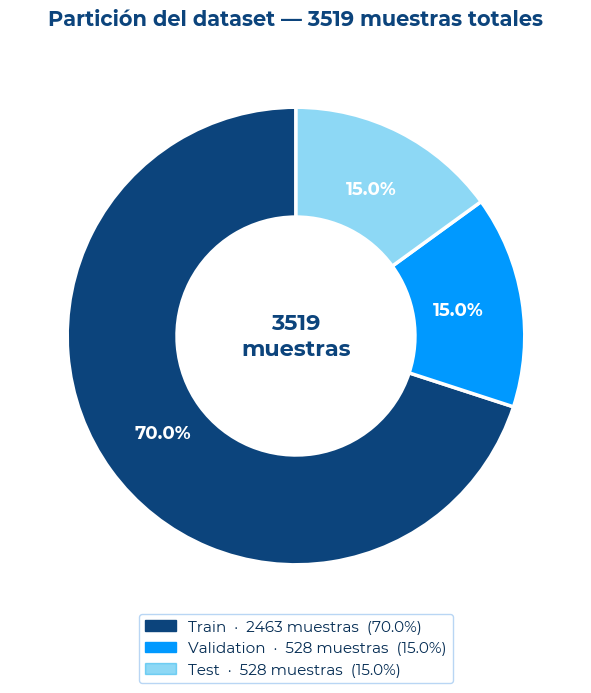

In [47]:
# ─── Figura 2: Donut con las proporciones train/val/test ─────────────────────
split_counts = DatasetFiltered["Split"].value_counts().reindex(SPLIT_ORDER, fill_value=0)
total = split_counts.sum()
pcts = split_counts / total * 100

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    split_counts,
    labels=None,
    colors=[SPLIT_COLORS[s] for s in SPLIT_ORDER],
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.72,
    startangle=90,
    wedgeprops=dict(width=0.48, edgecolor="white", linewidth=2.5),
)

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
    at.set_color("white")

# Leyenda
legend_labels = [
    f"{s}  ·  {int(split_counts[s])} muestras  ({pcts[s]:.1f}%)"
    for s in SPLIT_ORDER
]
patches = [
    mpatches.Patch(color=SPLIT_COLORS[s], label=lbl)
    for s, lbl in zip(SPLIT_ORDER, legend_labels)
]
ax.legend(
    handles=patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=1,
    frameon=True,
    framealpha=0.95,
    edgecolor=COLORS["border"],
    fontsize=11,
)

ax.set_title(
    f"Partición del dataset — {total} muestras totales",
    fontsize=15, fontweight="bold", color=COLORS["navy"], pad=18,
)

# Texto central en el donut
ax.text(0, 0, f"{total}\nmuestras", ha="center", va="center",
        fontsize=16, fontweight="bold", color=COLORS["navy"],
        linespacing=1.4)

plt.tight_layout()
SaveFig(fig, "Fig02_DistribucionSplit_Donut.png")
plt.show()

## 4. Figura 3 — Presencia de países por split

Guardada: /data/users/kabasmen/MethaneProjectTFM/Outputs/ResultsChapter_101622_101840/Figures_General/Fig03_PaisesPorSplit_Heatmap.png


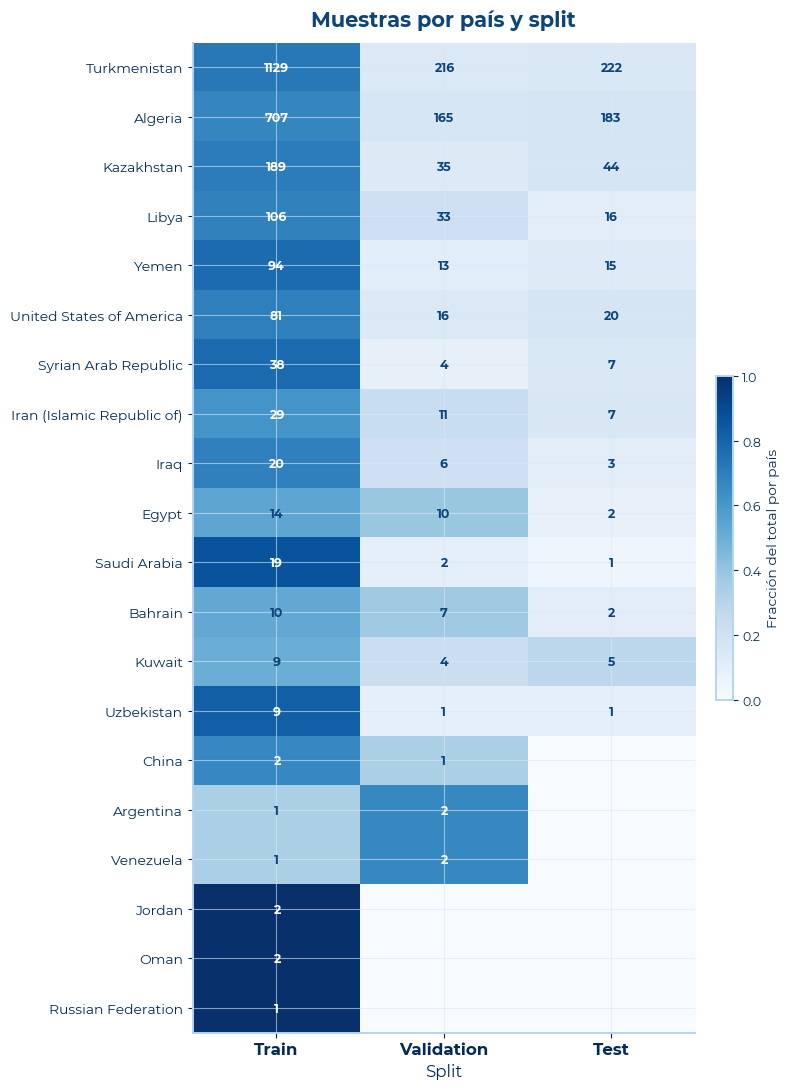

In [48]:
# ─── Figura 3: Heatmap de presencia de países por split ──────────────────────
# Tabla: filas = países, columnas = splits, valores = nº muestras
presence = (
    DatasetFiltered.groupby(["Country", "Split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SPLIT_ORDER, fill_value=0)
)
# Ordenar por total
presence = presence.loc[presence.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, max(5, len(presence) * 0.55)))

# Normalizar por fila para el color (fracción del total de ese país)
presence_norm = presence.div(presence.sum(axis=1), axis=0)

im = ax.imshow(
    presence_norm.values,
    cmap=plt.cm.Blues,
    aspect="auto",
    vmin=0, vmax=1,
)

ax.set_xticks(range(len(SPLIT_ORDER)))
ax.set_xticklabels(SPLIT_ORDER, fontsize=12, fontweight="bold")
ax.set_yticks(range(len(presence)))
ax.set_yticklabels(presence.index.tolist(), fontsize=10)

# Anotaciones con número real
for i in range(len(presence)):
    for j, split in enumerate(SPLIT_ORDER):
        val = int(presence.iloc[i, j])
        if val > 0:
            brightness = presence_norm.iloc[i, j]
            color = "white" if brightness > 0.55 else COLORS["navy"]
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=9, color=color, fontweight="bold")

ax.set_title(
    "Muestras por país y split",
    fontsize=15, fontweight="bold", color=COLORS["navy"], pad=12,
)
ax.set_xlabel("Split", fontsize=12, color=COLORS["text"])

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Fracción del total por país", fontsize=10, color=COLORS["text"])
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
SaveFig(fig, "Fig03_PaisesPorSplit_Heatmap.png")
plt.show()

## 5. Figura 4 — Total de muestras por país (simple)

Guardada: /data/users/kabasmen/MethaneProjectTFM/Outputs/ResultsChapter_101622_101840/Figures_General/Fig04_TotalMuestrasPorPais.png


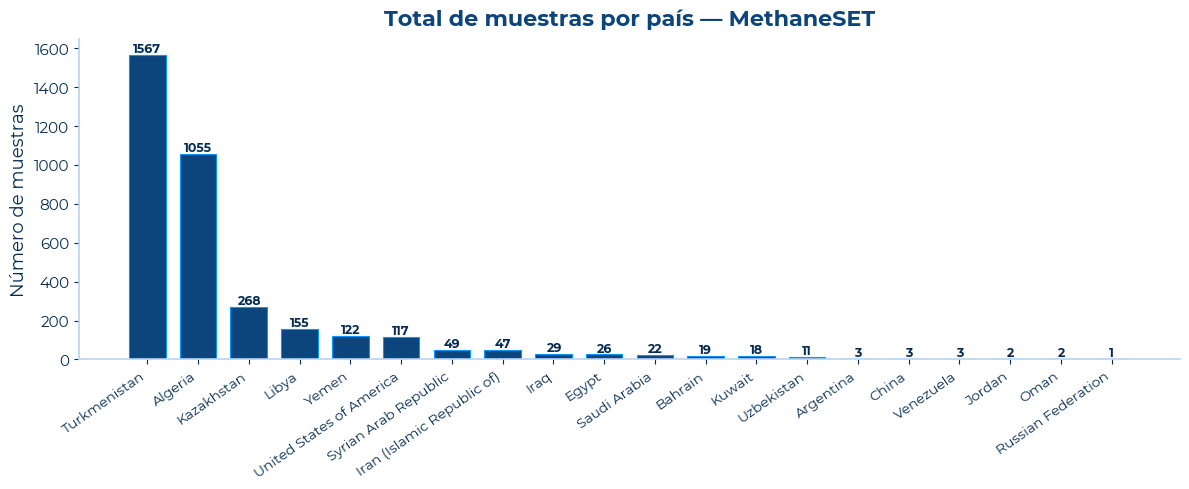

In [49]:
# ─── Figura 4: Barras verticales simples por país ────────────────────────────
country_counts = (
    DatasetFiltered["Country"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    range(len(country_counts)),
    country_counts.values,
    color=COLORS["navy"],
    edgecolor=COLORS["mid_blue"],
    linewidth=0.8,
    width=0.72,
)

# Etiquetas sobre barras
for bar, val in zip(bars, country_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        str(int(val)),
        ha="center", va="bottom",
        fontsize=9, color=COLORS["text"], fontweight="bold",
    )

ax.set_xticks(range(len(country_counts)))
ax.set_xticklabels(
    country_counts.index.tolist(),
    rotation=35, ha="right", fontsize=10,
)

StyleAxes(
    ax,
    title="Total de muestras por país — MethaneSET",
    xlabel=None,
    ylabel="Número de muestras",
)

ax.grid(False)

plt.tight_layout()
SaveFig(fig, "Fig04_TotalMuestrasPorPais.png")
plt.show()

## 6. Tabla resumen por país y split

In [ ]:
# Tabla resumen completa
summary = (
    DatasetFiltered.groupby(["Country", "Split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SPLIT_ORDER, fill_value=0)
)
summary["Total"] = summary.sum(axis=1)
summary = summary.sort_values("Total", ascending=False)
summary.loc["TOTAL"] = summary.sum()
print(f"\nResumen por país y split ({len(DatasetFiltered)} muestras):")
display(summary)


Resumen por país y split (3519 muestras):


Split,Train,Validation,Test,Total
Country,,,,
Turkmenistan,967,90,510,1567
Algeria,820,46,189,1055
Kazakhstan,219,25,24,268
Libya,102,11,42,155
Yemen,63,19,40,122
United States of America,35,0,82,117
Syrian Arab Republic,1,0,48,49
Iran (Islamic Republic of),14,1,32,47
Iraq,27,0,2,29


## 7. Próximas figuras a generar

Ejecutar las siguientes celdas para añadir figuras adicionales:

- **Fig 5** — Distribución de fluxrate (tasa de emisión) por split
- **Fig 6** — Distribución de tamaño de pluma (GTArea) por split  
- **Fig 7** — Mapa mundial con puntos por país (requiere `geopandas`)
- **Fig 8** — Porcentaje de plumas vs fondo por split

Ir añadiendo celdas a continuación según se necesiten.

Columna de fluxrate: detection:ch4_fluxrate


/tmp/ipykernel_3668201/2653379570.py:35: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Montserrat.
  plt.tight_layout()
/tmp/ipykernel_3668201/2541538711.py:65: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Montserrat.
  fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")


Guardada: /data/users/kabasmen/MethaneProjectTFM/Outputs/ResultsChapter_101622_101840/Figures_General/Fig05_DistribucionFluxrate_PorSplit.png


/data/users/kabasmen/.conda/envs/deep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Montserrat.
  fig.canvas.print_figure(bytes_io, **kw)


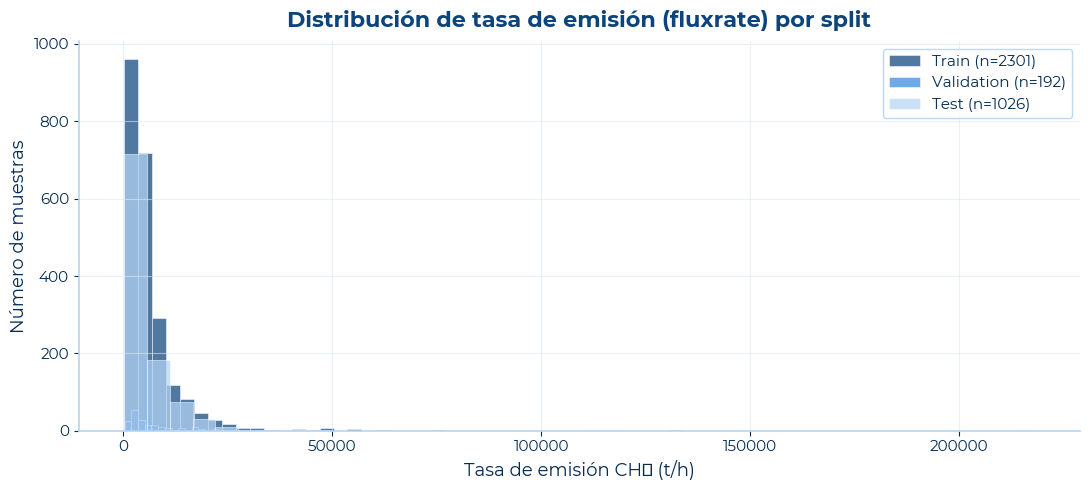

In [ ]:
# ─── Figura 5: Distribución de fluxrate por split ───────────────────────────
# Detectar columna de fluxrate
flux_col = next(
    (c for c in DatasetFiltered.columns if "flux" in c.lower() or "ch4_flux" in c.lower()),
    None
)

if flux_col is None:
    print("No se encontró columna de fluxrate en DatasetFiltered.")
    print("Columnas disponibles:", DatasetFiltered.columns.tolist())
else:
    print(f"Columna de fluxrate: {flux_col}")
    df_flux = DatasetFiltered[DatasetFiltered[flux_col].notna()].copy()

    fig, ax = plt.subplots(figsize=(11, 5))
    for split in SPLIT_ORDER:
        sub = df_flux[df_flux["Split"] == split][flux_col]
        if len(sub) == 0:
            continue
        ax.hist(
            sub, bins=40, alpha=0.72,
            color=SPLIT_COLORS[split],
            edgecolor="white", linewidth=0.5,
            label=f"{split} (n={len(sub)})",
        )

    StyleAxes(
        ax,
        title="Distribución de tasa de emisión (fluxrate) por split",
        xlabel="Tasa de emisión CH₄ (t/h)",
        ylabel="Número de muestras",
    )
    ax.legend(frameon=True, framealpha=0.9, edgecolor=COLORS["border"])

    plt.tight_layout()
    SaveFig(fig, "Fig05_DistribucionFluxrate_PorSplit.png")
    plt.show()

Gráfica de Transmitancia

Guardada: /data/users/kabasmen/MethaneProjectTFM/Outputs/ResultsChapter_101622_101840/Figures_General/Fig08_MethaneTransmittance.png


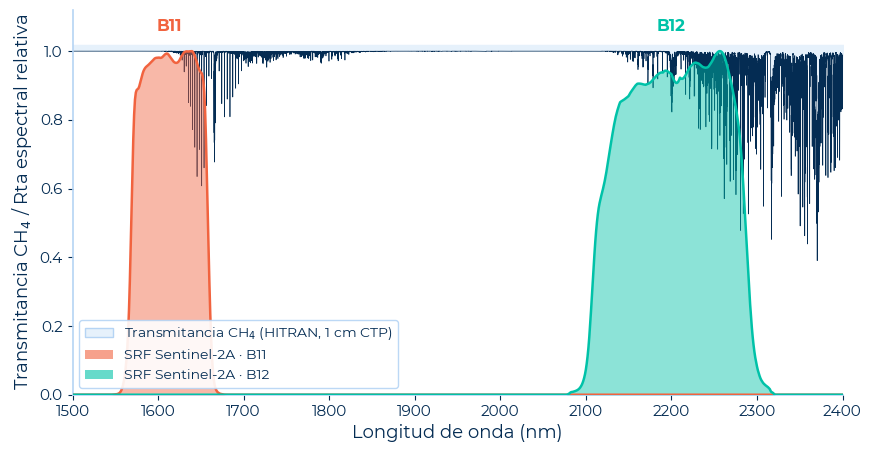

In [65]:
# ─── Cargar datos ──────────────────────────────────────────────────────────
DataDir = "/data/users/kabasmen/MethaneProjectTFM/Docs/datos_bandas_absorcion"


hit = pd.read_csv("/data/users/kabasmen/MethaneProjectTFM/Docs/ch4_hitran_swir.csv").sort_values("wavelength_nm").reset_index(drop=True)
srf = pd.read_csv("/data/users/kabasmen/MethaneProjectTFM/Docs/s2a_spectral_response_functions.csv")
srf = srf[(srf["SR_WL"] >= 1490) & (srf["SR_WL"] <= 2410)]

# ─── Transmitancia CH4 (Beer-Lambert, 1 cm CTP — convención estándar en literatura) ──
LOSCHMIDT = 2.6867811e19  # moleculas/cm^3 a STP
sigma = hit["absorption_coefficient"].values
wl_hit = hit["wavelength_nm"].values
transmittance = np.exp(-sigma * LOSCHMIDT * 1.0)

fig, ax = plt.subplots(figsize=(10, 5.2))

# Transmitancia: linea fina + relleno leve solo bajo la curva
ax.plot(wl_hit, transmittance, color=COLORS["text"], linewidth=0.5, zorder=2)
ax.fill_between(wl_hit, transmittance, 1.02, color=COLORS["pale"], linewidth=0, zorder=1)

# Colores llamativos y contrastantes para B11/B12 (fuera de la familia azul de fondo)
COL_B11 = "#F1633F"   # ambar/naranja
COL_B12 = "#00C2A8"   # turquesa vivo

ax.plot(srf["SR_WL"], srf["SR_AV_B11"], color=COL_B11, linewidth=1.8, zorder=4)
ax.fill_between(srf["SR_WL"], 0, srf["SR_AV_B11"], color=COL_B11, alpha=0.45, linewidth=0, zorder=3)

ax.plot(srf["SR_WL"], srf["SR_AV_B12"], color=COL_B12, linewidth=1.8, zorder=4)
ax.fill_between(srf["SR_WL"], 0, srf["SR_AV_B12"], color=COL_B12, alpha=0.45, linewidth=0, zorder=3)

ax.set_xlim(1500, 2400)
ax.set_ylim(0, 1.12)

StyleAxes(
    ax,
    xlabel="Longitud de onda (nm)",
    ylabel="Transmitancia CH$_4$ / Rta espectral relativa",
)
# ax.yaxis.set_label_coords(-0.09, 0.4) 
ax.grid(False)

# Etiquetas de banda
ax.annotate("B11", xy=(1613, 1.06), ha="center", fontsize=12, fontweight="bold", color=COL_B11)
ax.annotate("B12", xy=(2200, 1.06), ha="center", fontsize=12, fontweight="bold", color=COL_B12)

# Leyenda
legend_elems = [
    mpatches.Patch(facecolor=COLORS["pale"], edgecolor=COLORS["border"], label="Transmitancia CH$_4$ (HITRAN, 1 cm CTP)"),
    mpatches.Patch(facecolor=COL_B11, alpha=0.6, label="SRF Sentinel-2A · B11"),
    mpatches.Patch(facecolor=COL_B12, alpha=0.6, label="SRF Sentinel-2A · B12"),
]
leg = ax.legend(handles=legend_elems, loc="lower left", frameon=True,
                 facecolor="white", edgecolor=COLORS["border"], framealpha=0.9, fontsize=10)
for text in leg.get_texts():
    text.set_color(COLORS["text"])

fig.subplots_adjust(left=0.13, bottom=0.14) 
SaveFig(fig, "Fig08_MethaneTransmittance.png")
plt.show()